# 2. 标注与互评

## 学习目标
学习证据匹配、弃权、独立判断与一次匿名互评。

**数据来源：** 原有方法实验使用 `aiv/data.py` 的确定性合成样本；本页后半部读取 `results/final-analysis/` 的真实聚合观察或条件分析。两类结果分别标明范围。

## 运行准备
在项目环境中从干净内核运行全部单元。默认不读取 .env、不调用 API。

<!-- concept-illustration-v1:model-review -->
### 独立判断与复核

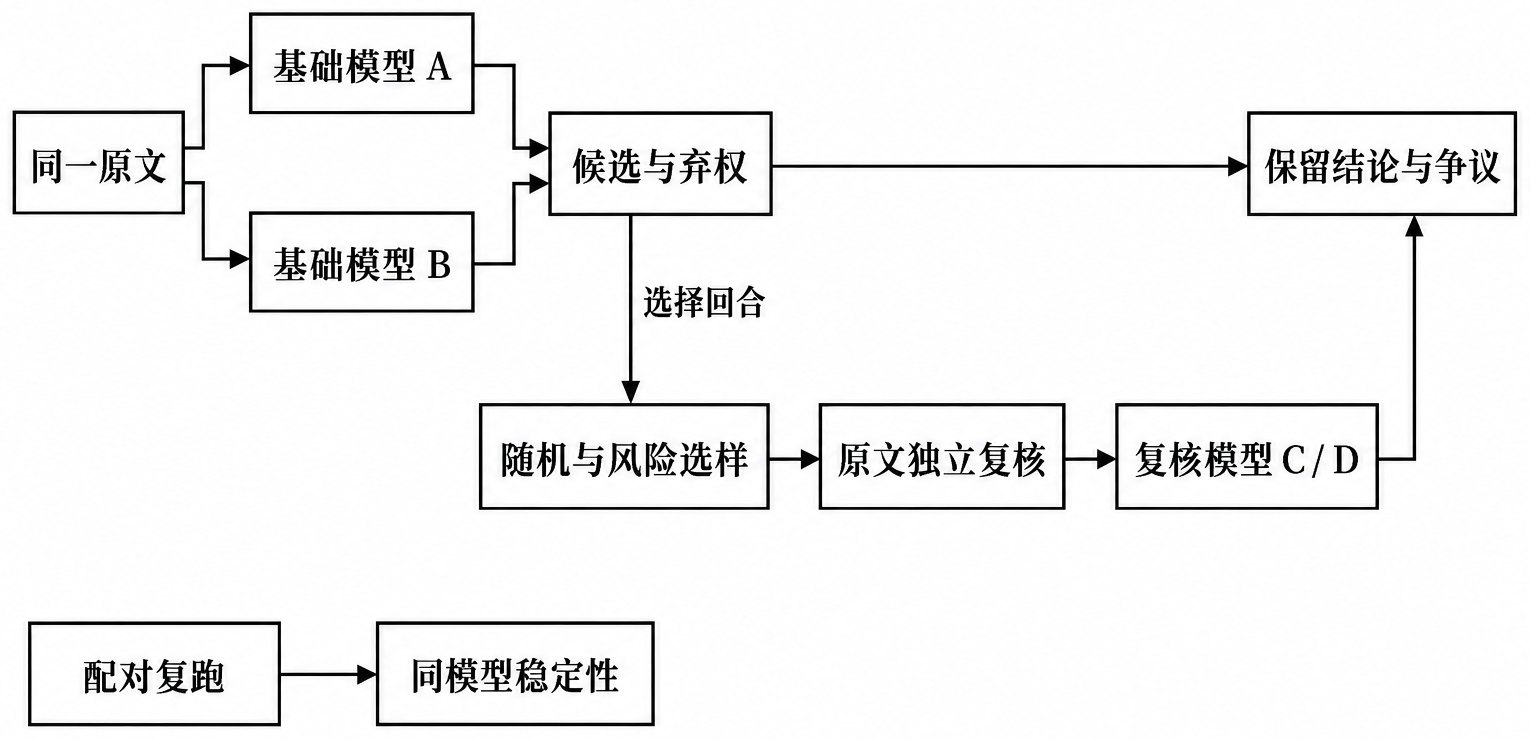

两基础模型与两复核模型分别独立判断任务、贡献两维。随机复核、风险复核和配对复跑保留各自分母；结论可继续弃权或保留争议。模型一致性与重复性各有对应统计量。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

## 结构化证据校验

In [2]:
from aiv.annotation import parse_judgment, majority

question = "我比较了两种假设的适用条件。"
example = dict(
    level=4,
    probabilities=[0, 0, 0.1, 0.8, 0.1, 0],
    evidence="比较了两种假设",
    reason="任务涉及假设比较",
    contribution_level=4,
    contribution_evidence="比较了两种假设",
    uncertain=True,
)
parsed = parse_judgment(json.dumps(example), question)
display(pd.DataFrame([parsed]).drop(columns="probabilities"))

,level,evidence,reason,contribution_level,contribution_evidence,uncertain
0,4,比较了两种假设,任务涉及假设比较,4,比较了两种假设,True


这是教学示例。原文匹配只能排除虚构引文，不能证明标签或推理正确。

## 重放公开合成对照缓存

In [3]:
cache_path = ROOT / "examples" / "synthetic-judge-cache.json"
cache = json.loads(cache_path.read_text("utf-8")) if cache_path.exists() else []
comparison = pd.DataFrame(
    [
        {
            "case": x["record"]["id"],
            "constructed": x["record"]["label"],
            "single": x["single_model"],
            "vote": x["vote"],
            "peer": x["peer_vote"],
            "final": x["final"],
        }
        for x in cache
    ]
)
display(
    comparison
    if len(comparison)
    else pd.DataFrame({"status": ["尚无经核验的公开缓存"]})
)

,case,constructed,single,vote,peer,final
0,control-0,1,1,1,1,1
1,control-1,2,2,2,2,2
2,control-2,3,3,5,5,3
3,control-3,4,4,4,4,4
4,control-4,5,5,5,5,5
5,control-5,6,6,5,5,5


缓存若存在，来自模型对合成对照的实际调用。构造标签不是独立人工金标准；真实准确率只能用盲审子集评估。

## 计算检查

In [4]:
assert majority([{"level": 4}, {"level": 4}, None]) is None
assert LIVE_API is False

## 材料衔接
本页重放合成缓存，并读取固定随机子集的真实流程比较；09 本继续展示全回合分布与同回合双维候选。

## 真实观察与前置探索：标注流程
固定分层随机复核的 352 个回合支持同题比较：分别读取两个快模型、两快严格合并及最终复核合并的状态。
候选、共同弃权、分歧、不确定和技术失败保留各自数量。高风险复核另有选择机制，在表中分列。
来源：`results/final-analysis/flow-comparison.csv`、`flow-transitions.csv` 与 `summary.json`。

In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("本目录未附真实聚合分析；以下真实结果保持空白，前面的合成实验仍可复算。"))
else:
    display(pd.DataFrame([{
        "分析输入": "results/final-analysis/summary.json",
        "冻结修订": final_summary["source"]["revision"],
        "快照清单 SHA-256": final_summary["source"]["manifest_sha256"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,分析输入,冻结修订,快照清单 SHA-256,真实回合,学生—学期
0,results/final-analysis/summary.json,t3,7e885ceecf12a180349369ed9ddfc962ad71f1ea270f68...,3515,401


### 前置探索：12 题独立判断、互评与仲裁
早期实验包含 6 条真实首问和 6 条人工构造样本，按原三票规则重算；两类样本分开统计。
三个数字票齐备且至少两票相同才形成独立或互评多数票，有效仲裁覆盖互评票。

In [6]:
if final_summary is not None and "pilot_exploration" in final_summary:
    pilot = final_summary["pilot_exploration"]
    pilot_comparison = final_csv("pilot-exploration.csv")
    display(pilot_comparison.rename(columns={"kind": "样本类型", "method": "方法", "record_denominator": "题目分母", "candidate_count": "候选数", "no_candidate_count": "无候选数", "comparison_method": "比较基线", "label_or_null_changes": "标签或弃权变化数", "gained_candidate": "新增候选", "lost_candidate": "退出候选", "both_candidate_label_changes": "共同候选标签变化"}))
    pilot_stages = []
    for group in pilot["by_kind"]:
        for stage, values in group["stages"].items():
            pilot_stages.append({"样本类型": group["kind"], "阶段": stage, "题目分母": group["record_denominator"], "输出数": values["outputs"], "有效输出": values["valid"], "无效输出": values["invalid"]})
    display(pd.DataFrame(pilot_stages))
    display(pd.DataFrame([{"样本类型": group["kind"], "同模型独立—互评双有效配对": group["same_model_independent_peer_valid_pairs"], "标签或弃权变化": group["same_model_task_label_or_null_changes"]} for group in pilot["by_kind"]]))

,样本类型,方法,题目分母,候选数,无候选数,比较基线,标签或弃权变化数,新增候选,退出候选,共同候选标签变化
0,real,single_model,6,3,3,single_model,0,0,0,0
1,real,vote,6,1,5,single_model,3,0,2,1
2,real,peer_vote,6,2,4,vote,1,1,0,0
3,real,final,6,2,4,peer_vote,2,0,0,2
4,synthetic,single_model,6,6,0,single_model,0,0,0,0
5,synthetic,vote,6,6,0,single_model,2,0,0,2
6,synthetic,peer_vote,6,6,0,vote,0,0,0,0
7,synthetic,final,6,6,0,peer_vote,1,0,0,1


,样本类型,阶段,题目分母,输出数,有效输出,无效输出
0,real,independent,6,18,18,0
1,real,peer,6,18,17,1
2,real,arbitration,6,3,3,0
3,synthetic,independent,6,18,18,0
4,synthetic,peer,6,18,18,0
5,synthetic,arbitration,6,1,1,0


,样本类型,同模型独立—互评双有效配对,标签或弃权变化
0,real,17,3
1,synthetic,18,2


真实 6 题在单 Claude、独立票、互评票、最终裁定下的候选数为 3 → 1 → 2 → 2；合成 6 题各阶段均为 6。
真实同模型双有效配对 17 对中改变 3 对，合成 18 对中改变 2 对。合成构造标签用于方法探索；它们不充当独立人工正确性基准。
这些旧模型、提示与输出限制下的结果与下面的 t3 随机子集分别阅读。

### t3：固定随机子集的同题状态

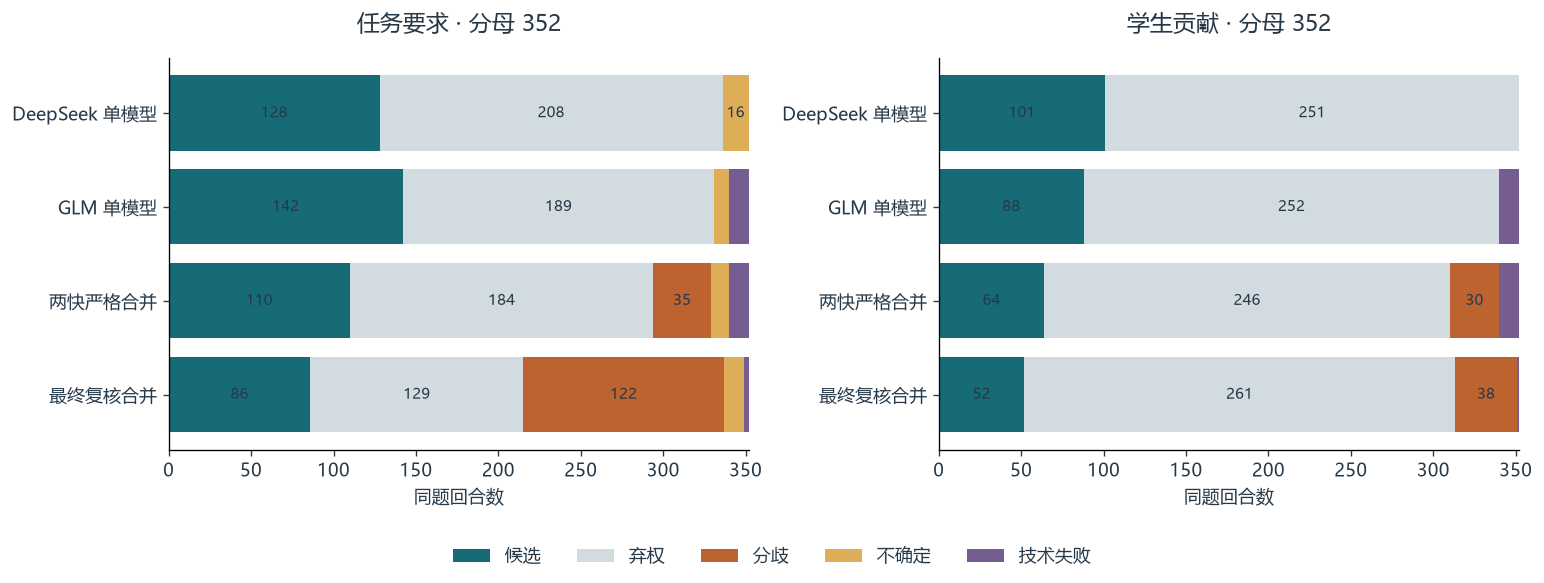

,stratum,dimension,method,turn_denominator,agreed,candidate_coverage,gained_candidate,lost_candidate,final_fast_fallback
0,random_audit,task,deepseek-v4.1-flash,352,128,0.364,18,0,0
1,random_audit,task,glm-5.3-flash,352,142,0.403,32,0,0
2,random_audit,task,fast_strict,352,110,0.312,0,0,0
3,random_audit,task,final_review_merge,352,86,0.244,7,31,7
4,random_audit,contribution,deepseek-v4.1-flash,352,101,0.287,37,0,0
5,random_audit,contribution,glm-5.3-flash,352,88,0.250,24,0,0
6,random_audit,contribution,fast_strict,352,64,0.182,0,0,0
7,random_audit,contribution,final_review_merge,352,52,0.148,13,25,9
8,high_risk,task,deepseek-v4.1-flash,827,206,0.249,167,0,0
9,high_risk,task,glm-5.3-flash,827,310,0.375,271,0,0


In [7]:
if final_summary is not None:
    flow = final_csv("flow-comparison.csv")
    methods = ["deepseek-v4.1-flash", "glm-5.3-flash", "fast_strict", "final_review_merge"]
    method_names = ["DeepSeek 单模型", "GLM 单模型", "两快严格合并", "最终复核合并"]
    status_labels = {"agreed": "候选", "abstained": "弃权", "disagreement": "分歧", "uncertain": "不确定", "technical_failure": "技术失败"}
    status_colors = ["#176B77", "#D2DCE0", "#BC632F", "#DDAE57", "#765D91"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.9), sharex=True)
    for ax, dimension, title in zip(axes, ["task", "contribution"], ["任务要求", "学生贡献"]):
        selected = flow.loc[flow.stratum.eq("random_audit") & flow.dimension.eq(dimension)].set_index("method").loc[methods]
        assert selected.turn_denominator.nunique() == 1
        assert selected[list(status_labels)].sum(axis=1).eq(selected.turn_denominator).all()
        left = np.zeros(len(selected))
        for (status, label), color in zip(status_labels.items(), status_colors):
            values = selected[status].to_numpy()
            ax.barh(range(4), values, left=left, color=color, label=label)
            for y, value, start in zip(range(4), values, left):
                if value >= 15:
                    ax.text(start + value / 2, y, str(int(value)), ha="center", va="center", fontsize=9)
            left += values
        ax.set_yticks(range(4), method_names)
        ax.invert_yaxis()
        ax.set(xlim=(0, int(selected.turn_denominator.iloc[0])), xlabel="同题回合数", title=f"{title} · 分母 {int(selected.turn_denominator.iloc[0])}")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
    fig.tight_layout(rect=(0, .09, 1, 1))
    save_figure(fig, "final-random-review-flow", "固定随机复核子集的同题状态比较；每种方法、每个维度均保留全部352回合。", kind="real", sources=["results/final-analysis/flow-comparison.csv", "results/final-analysis/summary.json"], notebook="02_标注与互评.ipynb")
    plt.show()
    display(flow[["stratum", "dimension", "method", "turn_denominator", "agreed", "candidate_coverage", "gained_candidate", "lost_candidate", "final_fast_fallback"]].round(3))

### 同题状态怎样变化
随机子集的任务候选由两快严格合并的 110 条变为最终合并的 86 条：原候选保留 79 条，新增 7 条，退出候选 31 条。
这是相同回合在给定合并规则下的输出变化；评价准确性仍需独立参考标签。

In [8]:
if final_summary is not None:
    transitions = final_csv("flow-transitions.csv")
    task_transitions = transitions.loc[transitions.stratum.eq("random_audit") & transitions.dimension.eq("task")]
    matrix = task_transitions.pivot(index="before_status", columns="after_status", values="count").reindex(index=status_labels, columns=status_labels).fillna(0).astype(int)
    assert matrix.to_numpy().sum() == 352
    assert matrix.loc["agreed"].sum() == 110 and matrix["agreed"].sum() == 86
    display(matrix.rename(index=status_labels, columns=status_labels))

after_status,候选,弃权,分歧,不确定,技术失败
before_status,,,,,
候选,79,1,24,6,0
弃权,0,120,64,0,0
分歧,2,7,22,3,1
不确定,4,1,4,1,1
技术失败,1,0,8,2,1
